CNN PER CLASSIFICAZIONE IMMAGINI REALI (TRANSFER LEARNING SU RESNET50)

Se ho visto più lontano è perchè stsavo sulle spalle dei giganti.
Nel Deep learning i giganti sono modelli come ResNet50
Perchè dovremmo passare settimane ad addestrare una rete da zero quando possiamo ereditare la saggezza visiva di un modello che ha già visto milioni di immagini

- Importazione pesi ImageNet: caricare la conoscenza universale in un modello custom
- Strategie di fine-tuning: sbloccare solo i neuroni necessari per la specializzazione
- Valutazione e inferenza: testare il modello su dasti reali

Eredita la Conoscenza
Perchè non addestare da zero una ResNet50
Addestrare una rete complessa come ResNet50 richiede settimane di calcolo e milioni di immagini. Grazie al Transfer Learning possiamo importare un modello che ha già imparato a vedere bordi, texture, e forme complesse tramite il dataset ImageNet.
L'architettura in Keras può essere caricata escludendo la testa di classificazione originale per adattarla ai nostri scopi specifici
Risparmiamo tempo, partiamo con un vantaggio competitivo enorme, una rete già addestrata.

ResNet50 come Feature Extractor
Il cuore del pre-addestramento
- Pesi ImageNeet: carichiamo i parametri ottimizzati su 1.2 milioni di immagini appartenenti a 1000 categorie diverse. Carichiamo la memoria storica del modello
- Parametro include_top: impostandolo a 'False' rimuoviamo i layer densi finali permettendoci di inserire un classificatore personalizzato.
- Layer Freezing: inizialmente blocchiamo tutti i layer della base convoluzione per non distruggere le feature già apprese. Mettiamo il gesso ai layer della base
- Il numero di parametri totali di ResNet50 supera 23 milioni ma solo una frazione sara addestrabile nelle prime fasi.

Configurazione di Ingresso
- Input Shape: ResNet50 richiede solitamente immagini quadrate (es. 224x224). Se il nostro dataset ha dimensioni diverse dobbiamo adattare il layer di input. 
- Preprocessing: E' fondamentale utilizzare le funzione 'preprocess_input' specifica di ResNet per scalare i pixel esattamente come durante l'addestramento originale. Ogni modello preaddestrato ha la sua funzione specifica per scalere i pixel, se usiamo la normalizzazione classica (0, 1) la rete vede tutto nebbioso perchè si aspetta i dati come su imagenet
- Global Average Pooling: invece di appiattire il volume finale usiamo spesso un pooling globale per ridurre la dimensionalità mantenendo l'informazione semantica.

La Gerarchia dei Filtri
Cosa stiamo importando davvero in termini di capacità visiva.
I primi layer di ResNet hanno imparato rilevatori di Gabor e colori universali. Questi filtri sono utili per quasi ogni compito di visone, dal riconoscimento di cellule mediche alla guida autonoma.
Importare questi pesi significa dare alla nostra rete una 'vista' già formata, permettendole di concentrarsi solo sulla comprensione delle classi specifiche del nostro problema.
Ora che la rete vede, dobbiamo insegnarle a riflettere sul nostro dominio, tramite il fine-tunning

L'Arte del Fine-Tuning
Adattare i blocchi profondi al nuovo dominio
Una volta che il nostro classificatore finale ha iniziato a convergere possiamo sbloccare una parte della base convoluzionale. Questo permette alla rete di raffinare i suoi filtri di alto livello
Non sblocchiamo tutta le rete, sarebbe un disastro. sblocchiamo solo gli ultimi blocchi residuali, quelle che si occupano delle forme più complesse e specifiche del dominio. La rete deve diventare più sensibile ai dettagli legati al nostro problema.

Unfreezing Selettivo
Raffinare la conoscenza.
- Ultimi blocchi: sblocchiamo solo i layer a partire dal blocco 5 per permettere alla rete di adattare le forme complesse al nuovo dataset
- Learning Rate ridotto: durante il fine-tuning usiamo un passo molto piccolo per evitare di stravolgere i pesi pre-addestrati. Se usassimo un passo troppo grande, l'ottimizzatore andrebbe a distruggere tutto lo studio del modello, dobbiamo usare un passo almeno 10 volte più piccolo rispetto a quello usato per la testa del modello.
- Monitoraggio della stabilità: il fine-tuning deve migliorare l'accuratezza senza causare l'esplosione della loss. L'accuratezza deve salire come una rampa dolce, senza picchi che indicherebbero un fallimento.
- Il learning rete per il fine-tuning è solitamente un ordine di grandezza inferiore a quello usato per la testa del modello

Meccanica del Fine-Tuning
Proprietà trainable: in Keras impostiamo 'layer.trainable=True' solo per gli strati selezionati dopo aver verificato i nomi tramite model.summary()
Iteriamo sui layer ed impostiamo a true solo quelli del blocco 5 mettendo gli altri a false.
Batch Normalization: un attenzione particolare va data ai layer di BN che spesso vengono mantenuti in modalità inferenza per preservare le statistiche di ImageNet, perchè le sue statistiche originali sono molto più robuste delle nostre
- Ricompilazione: ogni volta che cambiamo la proprietà 'trainable' di un layer è obbligatorio chiamare nuovamente 'model.compile' per rendere effettive le modifiche, e ricostruisce il grafo di calcolo.

Sbloccare troppo e troppo presto porta un rischio fatale

Prevenire il Catastrophic Forgetting
Non cancellare ciò che la rete sa già
Se sblocchiamo tutti i layer con un learning rate alto la rete dimenticherebbe immediatamente come vedere le forme generali cercando di adattarsi troppo velocemente ai nuovi dati.
Il fine-tuning è una chirurgia di precisione: vogliamo solo spostare leggermente i pesi degli ultimi layer per catturare le sfumature del nostro dataset
Abbiamo quindi addestrato il modello, adesso dobbiamo capire come se la cava nel mondo reale.

Valutazione su Data Reali
Validare il modello fuori dal laboratorio
Un modello di Transfer Learning può mostrare ottimi risultati sul training set ma fallire su immagini reali scattate in condizione diverse (luce, angolazione, rumore). Il mondo reale è sporco, ci sono luci diverse, angolazione diverse, quindi il modello deve essere valutato fuori dai dati puliti.
E' necessario interpretare le metriche di valutazoine e testare il modello su immagini mai viste prima di garantirne l'affidabilità

Quali sono i termometri per misurare questa salute?

Metriche di Performance
Oltre la semplice accuratezza
L'accuratezza da sola è bugiarda per capire se il modello scambia sistematicamente una label per l'altra
- Matrice di Confusione: essenziale per capire se il modello scambia classi simili nel nostro nuovo dataset
- Overfitting Check: confrontiamo le curve di training e validazione per assicurarci che il modello stia generalizzando
- Inference Time: misuriamo quanto tempo impiega ResNet50 per processare una singola immagine in un ambiente di produzione. ResNet 50 è un gigante e se l'applicazione deve girare su un telefono doabbiamo sapere quanto tempo ci mette
- L'errore di generalizzazione è la differenza tra la loss di addestramento e quella misurata su dati reali.

Test sul Campo
- Data Augmentation: per migliorare la valutazione su dati reali è utile testare il modello con leggere variazioni dell imput durante l'inferenza (TTA), anche in fase di test. Invece di dare una sola immagine all rete, ne diamo 5 versioni leggermente diverse e facciamo la media. E' come chiedere un parere a 3 amici diversi
- Interpretazione dei Risultati: Visualizzare le immagini classificate erroneamente aiuta a capire se il problema risiede nel dataset o nella profondità del fine-tuning. Spesso l'errore è comprensibile anche ad occhio umano
- Salvataggio finale:  una volta validato il modello va esportato nel formato 'SavedModel' per essere pronto per il deploy su server o dispositivi edge.

ResNet non è onnipotente, ha i suoi limiti di dominio

Invarianza del Dominio
Il salt tra ImageNet e il tuo dataset
ResNet50 è estremamente potente ma se il tuo dataset reale è drasticamente diverso (es. immagini termiche o radar o ecografie mediche) il Transfer Learning potrebbe richiedere strategia più agressive.
La valutazione continua è l'unica difesa contro il degrado delle performance quando i dati di input cambiano nel tempo o della qualità delle immagini.


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[INFO] Fase 1: Feature Extraction...
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.7968 - loss: 0.4199 - val_accuracy: 0.8570 - val_loss: 0.3251
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.8566 - loss: 0.3230 - val_accuracy: 0.8685 - val_loss: 0.3075
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 369s 1s/step - accuracy: 0.8689 - loss: 0.2993 - val_accuracy: 0.8675 - val_loss: 0.3016
[INFO] Fase 2: Fine-Tuning...
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.8158 - loss: 0.4025 - val_accuracy: 0.8565 - val_loss: 0.3398
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 371s 1s/step - accuracy: 0.8749 - loss: 0.2908 - val_accuracy: 0.8635 - val_loss: 0.3128
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 667s 3s/step - accuracy: 0.8970 - loss: 0.2456 - val_accuracy: 0.8830 - val_loss: 0.2861
63/63 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step


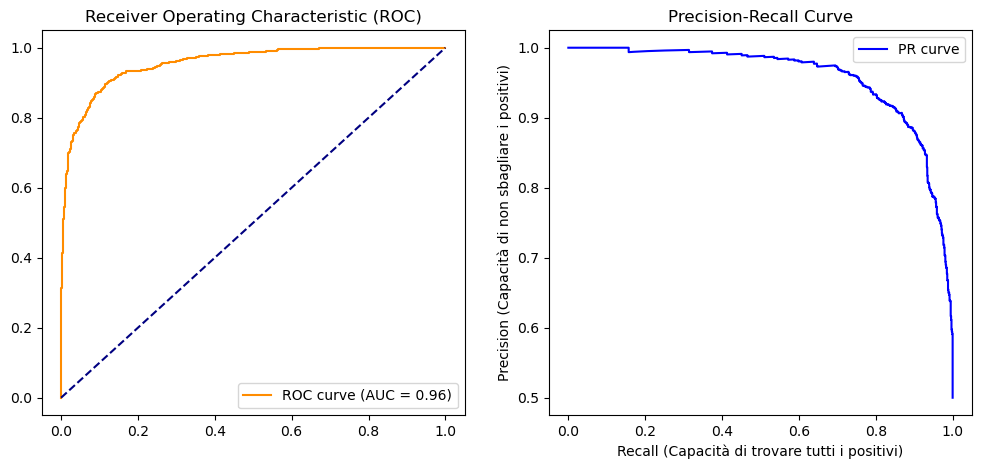

In [1]:
import os

# Configurazione del Backend: Fondamentale nel 2026. Keras 3 è "multi-backend".
# Impostando "torch", chiediamo a Keras di tradurre i suoi layer in moduli PyTorch nativi.
# Va fatto PRIMA di importare keras perché la scelta del motore di calcolo è immutabile dopo il caricamento.
os.environ["KERAS_BACKEND"] = "torch"

import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Scarichiamo il dataset: 50.000 immagini di training e 10.000 di test (32x32 pixel a colori).
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Funzione di filtraggio binario: essenziale per restringere il dominio del problema.
def filter_binary(x, y, c1, c2):
    # Creiamo una 'maschera booleana': True solo dove la classe è c1 o c2.
    mask = (y == c1) | (y == c2)
    
    # Applichiamo la maschera per estrarre solo le immagini desiderate.
    x_filtered = x[mask.flatten()]
    
    # Trasformiamo le etichette in 0 (per gatti, c1) e 1 (per cani, c2).
    # .astype(int) converte i Booleani risultanti in numeri interi (0 e 1).
    y_filtered = (y[mask.flatten()] == c2).astype(int) 
    return x_filtered, y_filtered

# Applichiamo il filtro: Classe 3 = Cat, Classe 5 = Dog.
x_train, y_train = filter_binary(x_train, y_train, 3, 5)
x_test, y_test = filter_binary(x_test, y_test, 3, 5)


# MobileNetV2: Un modello leggero ed efficiente basato su 'Inverted Residual Blocks'.
# include_top=False: Rimuoviamo il layer finale di ImageNet (che predice 1000 classi).
# weights="imagenet": Carichiamo i pesi già ottimizzati per riconoscere forme e texture universali.
base_model = keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False, 
    weights="imagenet"
)

# CONGELAMENTO (Freezing): Impostiamo trainable=False.
# Teoria: Vogliamo che i filtri visivi della base (che sanno già distinguere forme e colori) 
# non vengano modificati durante la prima fase, altrimenti i pesi casuali del nuovo "capo" 
# invierebbero gradienti forti che distruggerebbero le conoscenze pre-esistenti.
base_model.trainable = False

# --- Pipeline Funzionale Keras ---
# Input: Definiamo la forma d'ingresso delle immagini CIFAR10 (32x32x3).
inputs = keras.Input(shape=(32, 32, 3)) 

# Resizing: MobileNetV2 è stata addestrata su immagini grandi. 
# Fare upscaling a 160x160 migliora drasticamente la qualità delle feature estratte.
x = keras.layers.Resizing(160, 160)(inputs) 

# Preprocess_input: Normalizza i pixel. MobileNet si aspetta valori nel range [-1, 1].
x = keras.applications.mobilenet_v2.preprocess_input(x) 

# Backbone: Passiamo l'immagine nel modello base. 
# training=False è critico: mantiene i layer di Batch Normalization in modalità inferenza.
x = base_model(x, training=False) 

# GlobalAveragePooling2D: Riduce la mappa di feature (es. 5x5x1280) a un vettore singolo (1280).
# Più moderno e con meno parametri rispetto a un classico layer Flatten.
x = keras.layers.GlobalAveragePooling2D()(x) 

# Dropout: Spegne casualmente il 20% dei neuroni per forzare la rete a non dipendere da singoli 
# segnali, riducendo l'overfitting (la memorizzazione a memoria dei dati).
x = keras.layers.Dropout(0.2)(x) 

# Output: Sigmoid trasforma l'output in una probabilità tra 0 e 1.
# Formula: $S(x) = \frac{1}{1 + e^{-x}}$
outputs = keras.layers.Dense(1, activation="sigmoid")(x) 

model = keras.Model(inputs, outputs)

# Compilazione Fase 1: Usiamo Adam con un Learning Rate standard (0.001).
# loss="binary_crossentropy": La funzione di costo ideale per probabilità binarie.
# Formula: $L = -\frac{1}{N} \sum_{i=1}^N [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])


# FASE 1: Addestriamo solo la "testa" del modello (i layer densi aggiunti da noi).
print("[INFO] Fase 1: Feature Extraction...")
model.fit(x_train, y_train, epochs=3, validation_split=0.2, batch_size=32)

# FASE 2: FINE-TUNING
# Teoria: Ora sblocchiamo la base per permettere al modello di specializzare i suoi filtri 
# visivi profondi sulle caratteristiche specifiche di cani e gatti di CIFAR10.
base_model.trainable = True

# Strategia: Congeliamo i primi 100 layer (che vedono linee e bordi generici) e 
# sblocchiamo solo i layer finali (che vedono strutture complesse come orecchie o musi).
for layer in base_model.layers[:100]:
    layer.trainable = False

# CRITICO: Usiamo un Learning Rate minuscolo (1e-5). 
# Un passo troppo grande distruggerebbe i pesi di ImageNet (Catastrophic Forgetting).
model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="binary_crossentropy", metrics=["accuracy"])

print("[INFO] Fase 2: Fine-Tuning...")
model.fit(x_train, y_train, epochs=3, validation_split=0.2, batch_size=32)

# Salvataggio: Il formato .keras è un pacchetto ZIP che contiene tutto il necessario per il deploy.
model.save("classifier_immagini_2026.keras")


# Predict: Otteniamo le probabilità (es. 0.85 invece di un secco "Cane").
y_pred_probs = model.predict(x_test).ravel()

# ROC Curve: Analizza il trade-off tra Veri Positivi e Falsi Positivi.
# L'AUC (Area Under Curve) indica quanto il modello è bravo a separare le due classi (1.0 è perfetto).
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve: Più indicata se le classi fossero sbilanciate.
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)

# Visualizzazione con Matplotlib
plt.figure(figsize=(12, 5))

# Sottografo ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Linea del caso (50/50)
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()

# Sottografo PR
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', label='PR curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall (Capacità di trovare tutti i positivi)')
plt.ylabel('Precision (Capacità di non sbagliare i positivi)')
plt.legend()

plt.show()